# Procedure for Adadetect

## Imports

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, Subset, ConcatDataset, DataLoader, TensorDataset
from torchvision import datasets, transforms
from medmnist import ChestMNIST, DermaMNIST, BreastMNIST, BloodMNIST, OCTMNIST
from medmnist import INFO


from sklearn.datasets import fetch_openml
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from procedure import AdaDetectERM

np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Using device: {device}")

Using device: cuda


In [50]:
def get_images(dataset, indices):
    images = []
    for idx in indices:
        img, _ = dataset[idx]
        images.append(img)
    return torch.stack(images)


In [51]:
def get_fdp(ytrue, rejection_set):
    """
    """

    if rejection_set.size:
        fdp = np.sum(ytrue[rejection_set] == 0) / len(rejection_set)
        tdp = np.sum(ytrue[rejection_set] == 1) / np.sum(ytrue==1)
    else: 
        fdp=0
        tdp=0
    return fdp, tdp

## Create Classifiers

### Adadetect's CNN implementation

In [39]:
class BinaryConvNet(nn.Module):
    def __init__(self, in_channels):
        super(BinaryConvNet, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())
        
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class ADACNNClassifier:
    def __init__(self, in_channels=1, epochs=10, lr=1e-3, batch_size=128):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.in_channels = in_channels
        self.model = BinaryConvNet(in_channels).to(device)

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True
        )

        opt = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.BCEWithLogitsLoss()

        self.model.train()
        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)
                yb = yb.unsqueeze(-1)

                opt.zero_grad()
                loss = loss_fn(self.model(xb), yb)
                loss.backward()
                opt.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(X, batch_size=self.batch_size)

        self.model.eval()
        out = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                proba_class_1 = nn.functional.sigmoid(self.model(xb)).cpu()
                proba_class_0 = 1 - proba_class_1
                # Return (N, 2) shape: [prob_class_0, prob_class_1]
                out.append(torch.cat([proba_class_0, proba_class_1], dim=1))

        return torch.cat(out).numpy()

### CNN

In [40]:
class CNNClassifier:
    def __init__(self, in_channels=1, epochs=10, lr=1e-3, batch_size=128):
        self.epochs = epochs
        self.lr = lr
        self.batch_size = batch_size
        self.in_channels = in_channels

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        ).to(device)

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True
        )

        opt = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        self.model.train()
        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                opt.zero_grad()
                loss = loss_fn(self.model(xb), yb)
                loss.backward()
                opt.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(X, batch_size=self.batch_size)

        self.model.eval()
        out = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                out.append(torch.softmax(self.model(xb), dim=1).cpu())

        return torch.cat(out).numpy()

### RESNET

In [41]:
class ResNetClassifier:
    def __init__(self, in_channels=1, lr=1e-3, epochs=10, batch_size=128):
        self.in_channels = in_channels
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size

        # ---- Load pretrained ResNet18 ----
        self.model = models.resnet18(weights=None)

        # ---- Replace first conv layer for arbitrary channels ----
        self.model.conv1 = nn.Conv2d(
            in_channels,
            64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # ---- Replace classifier head for binary task ----
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)

        self.model = self.model.to(device)

    def fit(self, X, y):
        X = torch.tensor(X, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(X, y),
            batch_size=self.batch_size,
            shuffle=True,
            pin_memory=True
        )

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        loss_fn = nn.CrossEntropyLoss()

        self.model.train()

        for _ in range(self.epochs):
            for xb, yb in loader:
                xb = xb.to(device, non_blocking=True)
                yb = yb.to(device, non_blocking=True)

                optimizer.zero_grad()
                loss = loss_fn(self.model(xb), yb)
                loss.backward()
                optimizer.step()

    def predict_proba(self, X):
        X = torch.tensor(X, dtype=torch.float32)

        loader = torch.utils.data.DataLoader(X, batch_size=self.batch_size)

        self.model.eval()
        outs = []

        with torch.no_grad():
            for xb in loader:
                xb = xb.to(device)
                outs.append(torch.softmax(self.model(xb), dim=1).cpu())

        return torch.cat(outs).numpy()

## Load Data

### MNIST

In [42]:
dataset_name = 'mnist'
train_data = datasets.MNIST(
    root = 'data',
    train=True,                         
    transform = transforms.ToTensor(), 
    download = True,            
)

inlr_labels=[4]
outlr_labels=[9]
print(train_data)
inlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(inlr_labels)).any(-1).nonzero(as_tuple=True)[0]
outlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(outlr_labels)).any(-1).nonzero(as_tuple=True)[0]

# Get the actual images instead of just indices
inlr = train_data.data[inlr_idx].float()
outlr = train_data.data[outlr_idx].float()

print(len(inlr), len(outlr))
print(inlr.shape, outlr.shape)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()
5842 5949
torch.Size([5842, 28, 28]) torch.Size([5949, 28, 28])


C:\Users\h4sor\AppData\Local\Temp\ipykernel_14684\2255411318.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(inlr_labels)).any(-1).nonzero(as_tuple=True)[0]
C:\Users\h4sor\AppData\Local\Temp\ipykernel_14684\2255411318.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  outlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(outlr_labels)).any(-1).nonzero(as_tuple=True)[0]


### Fashion MNIST

Fashion MNIST Labels: 
0=T-shirt 1=Trouser, 2=Pullover, 3=Dress, 4=Coat (inlier), 5=Sandal, 6=Shirt, 7=Sneaker, 8=Bag, 9=Ankle boot (outlier)

In [ ]:
dataset_name = 'fashion_mnist'
train_data = datasets.FashionMNIST(
    root = 'data',
    train=True,                         
    transform = transforms.ToTensor(), 
    download = True,            
)


inlr_labels=[4] 
outlr_labels=[9] 
print(train_data)
inlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(inlr_labels)).any(-1).nonzero(as_tuple=True)[0]
outlr_idx = (torch.tensor(train_data.targets)[..., None] == torch.tensor(outlr_labels)).any(-1).nonzero(as_tuple=True)[0]

# Get the actual images instead of just indices
inlr = train_data.data[inlr_idx].float()
outlr = train_data.data[outlr_idx].float()

print(len(inlr), len(outlr))
print(inlr.shape, outlr.shape)

### Chest MNIST

In [ ]:
dataset_name = 'ChestMNIST'
train_data = ChestMNIST(
    split='train',
    download=False,
    root='data',
    transform=transforms.ToTensor()
)
print(train_data)
targets = torch.tensor(train_data.labels)
inlr = (targets.sum(dim=1) == 0).nonzero(as_tuple=True)[0]  # Healthy (no abnormalities)
outlr = (targets.sum(dim=1) > 0).nonzero(as_tuple=True)[0]  # Sick (has abnormalities)
inlr= get_images(train_data, inlr)
outlr = get_images(train_data, outlr)


### Derma MNIST

In [ ]:
dataset_name = 'DermaMNIST'
train_data = DermaMNIST(split='train', download=True, root='data', transform=transforms.ToTensor())
test_data = DermaMNIST(split='test', download=True, root='data', transform=transforms.ToTensor())
val_data = DermaMNIST(split='val', download=True, root='data', transform=transforms.ToTensor())

# Extract and concatenate labels before merging datasets
train_labels = train_data.labels
test_labels = test_data.labels
val_labels = val_data.labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])

# Merge datasets
train_data = ConcatDataset([train_data, val_data, test_data])

# Attach labels to the merged dataset
train_data.labels = all_labels

print(len(train_data),train_data[0][0].shape)


# DermaMNIST Skin Lesion Classification
# 0 → Actinic keratoses & intraepithelial carcinoma (Precancerous/early cancer)
# 1 → Basal cell carcinoma (Cancer)
# 2 → Benign keratosis-like lesions (Benign)
# 3 → Dermatofibroma (Benign)
# 4 → Melanoma (Dangerous/potentially fatal)
# 5 → Melanocytic nevi/moles (Usually benign)
# 6 → Vascular lesions (Benign)

targets_labels = train_data.labels.squeeze()  # Get label indices
benign_labels = [2, 3, 5, 6 ]  # Benign lesions
non_benign_labels = [0, 1, 4]  # Precancerous, cancer, dangerous

# Create indices for benign (inlr) and non-benign (outlr)
inlr_idx = np.where(np.isin(targets_labels, benign_labels))[0]  # Benign
outlr_idx = np.where(np.isin(targets_labels, non_benign_labels))[0]  # Non-benign/dangerous
inlr= get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)

plt.imshow(inlr[0].permute(1, 2, 0))

### OCTMNIST

In [ ]:
dataset_name = 'OCTMNIST'
train_data = OCTMNIST(split='train', download=True, root='data', transform=transforms.ToTensor())
test_data = OCTMNIST(split='test', download=True, root='data', transform=transforms.ToTensor())
val_data = OCTMNIST(split='val', download=True, root='data', transform=transforms.ToTensor())

# Extract and concatenate labels before merging datasets
train_labels = train_data.labels
test_labels = test_data.labels
val_labels = val_data.labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])

# Merge datasets
train_data = ConcatDataset([train_data, val_data, test_data])

# Attach labels to the merged dataset
train_data.labels = all_labels
print(len(train_data), train_data[0][0].shape)

# OCTMNIST Ophthalmology Classification
# 0 → Choroidal neovascularization (Disease)
# 1 → Diabetic macular edema (Disease)
# 2 → Drusen (Disease)
# 3 → Normal (Healthy/inlier)

targets_labels = train_data.labels.squeeze()  # Get label indices
normal_labels = [3]  # Normal (healthy)
disease_labels = [0, 1, 2]  # Diseases (abnormal)

# Create indices for normal (inlr) and disease (outlr)
inlr_idx = np.where(np.isin(targets_labels, normal_labels))[0]  # Normal
outlr_idx = np.where(np.isin(targets_labels, disease_labels))[0]  # Diseases
inlr = get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)

print(f"Normal (inlr): {inlr.shape}, Disease (outlr): {outlr.shape}")
plt.imshow(inlr[0].permute(1, 2, 0))

### BloodMNIST

In [ ]:
dataset_name = 'BloodMNIST'
train_data = BloodMNIST(split='train', download=True, root='data', transform=transforms.ToTensor())
test_data = BloodMNIST(split='test', download=True, root='data', transform=transforms.ToTensor())
val_data = BloodMNIST(split='val', download=True, root='data', transform=transforms.ToTensor())

# Extract and concatenate labels before merging datasets
train_labels = train_data.labels
test_labels = test_data.labels
val_labels = val_data.labels
all_labels = np.concatenate([train_labels, val_labels, test_labels])

# Merge datasets
train_data = ConcatDataset([train_data, val_data, test_data])

# Attach labels to the merged dataset
train_data.labels = all_labels
print(len(train_data), train_data[0][0].shape)

# BloodMNIST Blood Cell Classification
# 0 → Basophil (Normal)
# 1 → Eosinophil (Normal)
# 2 → Erythroblast (Abnormal - immature RBC)
# 3 → Immature granulocytes (Abnormal - myelocytes, metamyelocytes, promyelocytes)
# 4 → Lymphocyte (Normal)
# 5 → Monocyte (Normal)
# 6 → Neutrophil (Normal)
# 7 → Platelet (Normal)

targets_labels = train_data.labels.squeeze()  # Get label indices
normal_labels = [0, 1, 4, 5, 6, 7]  # Normal blood cells
abnormal_labels = [2, 3]  # Abnormal/immature cells

# Create indices for normal (inlr) and abnormal (outlr)
inlr_idx = np.where(np.isin(targets_labels, normal_labels))[0]  # Normal
outlr_idx = np.where(np.isin(targets_labels, abnormal_labels))[0]  # Abnormal
inlr = get_images(train_data, inlr_idx)
outlr = get_images(train_data, outlr_idx)

print(f"Normal (inlr): {inlr.shape}, Abnormal (outlr): {outlr.shape}")
plt.imshow(inlr[0].permute(1, 2, 0))

### Kaggle Dog vs Cat

In [18]:
import os
import urllib.request
import zipfile
from PIL import Image
dataset_name = 'DogsVsCats'
# Download dogs-vs-cats dataset
dataset_path = 'data/dogs_vs_cats'
os.makedirs(dataset_path, exist_ok=True)

zip_path = 'data/dogs_vs_cats.zip'
if not os.path.exists(zip_path):
    print("Downloading dogs-vs-cats dataset...")
    url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete!")
    
    # Extract dataset
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('data/')
    print("Extraction complete!")

# Load and prepare data
from pathlib import Path
import numpy as np

dogs_dir = Path('data/PetImages/Dog')
cats_dir = Path('data/PetImages/Cat')

# Load images
dogs_images = []
cats_images = []

for img_file in sorted(list(dogs_dir.glob('*.jpg'))[:6000]):  # Load first 6000
    try:
        img = Image.open(img_file).convert('RGB').resize((28, 28))
        dogs_images.append(np.array(img))
    except:
        pass

for img_file in sorted(list(cats_dir.glob('*.jpg'))[:6000]):  # Load first 6000
    try:
        img = Image.open(img_file).convert('RGB').resize((28, 28))
        cats_images.append(np.array(img))
    except:
        pass

# Convert to tensors
dogs_images = torch.tensor(np.array(dogs_images), dtype=torch.float32)
cats_images = torch.tensor(np.array(cats_images), dtype=torch.float32)

inlr = dogs_images  # Dogs as normal class
outlr = cats_images  # Cats as outlier class

print(f"Dogs: {inlr.shape}, Cats: {outlr.shape}")

Dogs: torch.Size([5999, 28, 28, 3]), Cats: torch.Size([6000, 28, 28, 3])


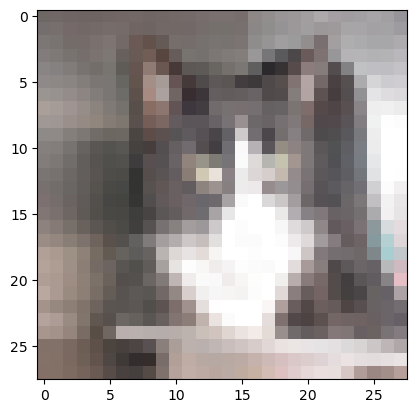

In [19]:
plt.imshow(outlr[110].numpy().astype(np.uint8))

### CreditCard

In [34]:
dataset = fetch_openml(name='creditcard', version=1, as_frame=False)
X = dataset.data
y = dataset.target.astype(float)
outlr, inlr = X[y==1], X[y==0]

# Apply Procedure

## Parameters

In [ ]:
m1 = 100
m0 = 900
test_idx = np.random.choice(len(inlr), replace=False, size=m0)
test0 = inlr[test_idx].numpy() if torch.is_tensor(inlr) else inlr[test_idx]
test1_idx = np.random.choice(len(outlr), replace=False, size=m1)
test1 = outlr[test1_idx].numpy() if torch.is_tensor(outlr) else outlr[test1_idx]
x = np.concatenate([test0, test1])

#NTS
n=4000

k = 3000

remaining_idx = np.setdiff1d(np.arange(len(inlr)), test_idx)
remaining_idx = remaining_idx[:n]  # Take only first n samples to match mnist
xnull = inlr[remaining_idx].numpy() if torch.is_tensor(inlr) else inlr[remaining_idx]
#apply AdaDetect with ERM approach, with k=3000 (see notations of the paper)
level=0.1

## Apply

### Restructure data for different Classifiers

In [115]:
if dataset_name == 'mnist' or dataset_name == 'fashion_mnist':
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
  
    x_cnn = x.reshape(x.shape[0], 1, x.shape[1], x.shape[2])  # (1000, 1, 28, 28)
    xnull_cnn = xnull.reshape(xnull.shape[0], 1, xnull.shape[1], xnull.shape[2])
elif dataset_name == 'creditcard':
    xnull_flatten = xnull
    x_flatten = x


elif dataset_name == 'ChestMNIST' or dataset_name == "OCTMNIST":
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
    
    # ChestMNIST is already (batch, 1, 28, 28) from ToTensor()
    x_cnn = x 
    xnull_cnn = xnull 

elif dataset_name == 'DogsVsCats':
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
    
    # RGB images: (batch, 28, 28, 3) -> (batch, 3, 28, 28)
    x_cnn = x.permute(0, 3, 1, 2) if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32).permute(0, 3, 1, 2)
    xnull_cnn = xnull.permute(0, 3, 1, 2) if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32).permute(0, 3, 1, 2)

elif dataset_name == 'DermaMNIST' or dataset_name == 'BloodMNIST':
    xnull_flatten = xnull.reshape(xnull.shape[0], -1)
    x_flatten = x.reshape(x.shape[0], -1)
    
    # Data from DermaMNIST is already (batch, 3, 28, 28) from ToTensor()
    x_cnn = x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=torch.float32)
    xnull_cnn = xnull if isinstance(xnull, torch.Tensor) else torch.tensor(xnull, dtype=torch.float32)

true_labels = np.concatenate([np.zeros(m0), np.ones(m1)])


### ADACNN

In [122]:
ACNN = ADACNNClassifier(in_channels=x_cnn.shape[1], epochs=10, lr=1e-3, batch_size=128)
proc = AdaDetectERM(scoring_fn = ACNN, split_size=k/n)
S_acnn = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set

fdp_acnn, tdp_acnn = get_fdp(true_labels, S_acnn)
print(f"ACNN - Rejections: {len(S_acnn)}, TDP: {tdp_acnn:.4f}, FDP: {fdp_acnn:.4f}")

ACNN - Rejections: 83, TDP: 0.8100, FDP: 0.0241


C:\Users\h4sor\AppData\Local\Temp\ipykernel_14684\20442710.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


### Randomforest

In [88]:
rfc = RandomForestClassifier(max_depth=10)
proc = AdaDetectERM(scoring_fn = rfc, split_size=k/n) 
S_rf = proc.apply(x_flatten, level, xnull_flatten)#gives the rejection set 

fdp_rf, tdp_rf = get_fdp(true_labels, S_rf)
print(f"Random Forest - Rejections: {len(S_rf)}, TDP: {tdp_rf:.4f}, FDP: {fdp_rf:.4f}")

Random Forest - Rejections: 0, TDP: 0.0000, FDP: 0.0000


### CNN 

In [89]:
cnn = CNNClassifier(in_channels=x_cnn.shape[1])

proc = AdaDetectERM(scoring_fn = cnn, split_size=k/n) 
S_cnn = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set

fdp_cnn, tdp_cnn = get_fdp(true_labels, S_cnn)
print(f"CNN - Rejections: {len(S_cnn)}, TDP: {tdp_cnn:.4f}, FDP: {fdp_cnn:.4f}")

CNN - Rejections: 0, TDP: 0.0000, FDP: 0.0000


C:\Users\h4sor\AppData\Local\Temp\ipykernel_14684\1697163977.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


### Resnet

In [90]:
rnn = ResNetClassifier(in_channels=x_cnn.shape[1])

proc = AdaDetectERM(scoring_fn = rnn, split_size=k/n)
S_resnet = proc.apply(x_cnn, level, xnull_cnn) #gives the rejection set


fdp_resnet, tdp_resnet = get_fdp(true_labels, S_resnet)
print(f"ResNet - Rejections: {len(S_resnet)}, TDP: {tdp_resnet:.4f}, FDP: {fdp_resnet:.4f}")

C:\Users\h4sor\AppData\Local\Temp\ipykernel_14684\2909087514.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X, dtype=torch.float32)


ResNet - Rejections: 42, TDP: 0.4100, FDP: 0.0238


### K nearest neighbor

In [91]:
knn = KNeighborsClassifier(3)
proc = AdaDetectERM(scoring_fn = knn, split_size=k/n) 
S_knn = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_knn, tdp_knn = get_fdp(true_labels, S_knn)
print(f"KNN - Rejections: {len(S_knn)}, TDP: {tdp_knn:.4f}, FDP: {fdp_knn:.4f}")

KNN - Rejections: 0, TDP: 0.0000, FDP: 0.0000


### MLP

In [92]:
mlp = MLPClassifier(max_iter=300)
proc = AdaDetectERM(scoring_fn = mlp, split_size=k/n)
S_mlp = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_mlp, tdp_mlp = get_fdp(true_labels, S_mlp)
print(f"MLP - Rejections: {len(S_mlp)}, TDP: {tdp_mlp:.4f}, FDP: {fdp_mlp:.4f}")

MLP - Rejections: 0, TDP: 0.0000, FDP: 0.0000


### Logistic Regression

In [93]:
lr = LogisticRegression(max_iter=1000)
proc = AdaDetectERM(scoring_fn = lr, split_size=k/n) 
S_lr = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_lr, tdp_lr = get_fdp(true_labels, S_lr)
print(f"Logistic Regression - Rejections: {len(S_lr)}, TDP: {tdp_lr:.4f}, FDP: {fdp_lr:.4f}")

Logistic Regression - Rejections: 0, TDP: 0.0000, FDP: 0.0000


c:\Users\h4sor\miniforge3\envs\dl\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Decision Tree

In [94]:
dt = DecisionTreeClassifier(max_depth=10)
proc = AdaDetectERM(scoring_fn = dt, split_size=k/n) 
S_dt = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_dt, tdp_dt = get_fdp(true_labels, S_dt)
print(f"Decision Tree - Rejections: {len(S_dt)}, TDP: {tdp_dt:.4f}, FDP: {fdp_dt:.4f}")

Decision Tree - Rejections: 0, TDP: 0.0000, FDP: 0.0000


### Adaboost

In [95]:
ada = AdaBoostClassifier()
proc = AdaDetectERM(scoring_fn = ada, split_size=k/n)
S_adaB = proc.apply(x_flatten, level, xnull_flatten) #gives the rejection set


fdp_adaB, tdp_adaB = get_fdp(true_labels, S_adaB)
print(f"AdaBoost - Rejections: {len(S_adaB)}, TDP: {tdp_adaB:.4f}, FDP: {fdp_adaB:.4f}")

AdaBoost - Rejections: 0, TDP: 0.0000, FDP: 0.0000


### Results Summary

In [96]:
# Collect results from all classifiers
results = []

# ACNN
if 'S_acnn' in locals() and len(S_acnn) > 0:
    results.append(['ADACNN', len(S_acnn), tdp_acnn, fdp_acnn])
else:
    results.append(['ADACNN', 0, np.nan, np.nan])

# RandomForest
if 'S_rf' in locals() and len(S_rf) > 0:
    results.append(['RandomForest', len(S_rf), tdp_rf, fdp_rf])
else:
    results.append(['RandomForest', 0, np.nan, np.nan])

# CNN
if 'S_cnn' in locals() and len(S_cnn) > 0:
    results.append(['CNN', len(S_cnn), tdp_cnn, fdp_cnn])
else:
    results.append(['CNN', 0, np.nan, np.nan])

# ResNet
if 'S_resnet' in locals() and len(S_resnet) > 0:
    results.append(['ResNet', len(S_resnet), tdp_resnet, fdp_resnet])
else:
    results.append(['ResNet', 0, np.nan, np.nan])

# KNN
if 'S_knn' in locals() and len(S_knn) > 0:
    results.append(['KNN', len(S_knn), tdp_knn, fdp_knn])
else:
    results.append(['KNN', 0, np.nan, np.nan])

# MLP
if 'S_mlp' in locals() and len(S_mlp) > 0:
    results.append(['MLP', len(S_mlp), tdp_mlp, fdp_mlp])
else:
    results.append(['MLP', 0, np.nan, np.nan])

# Logistic Regression
if 'S_lr' in locals() and len(S_lr) > 0:
    results.append(['Logistic Regression', len(S_lr), tdp_lr, fdp_lr])
else:
    results.append(['Logistic Regression', 0, np.nan, np.nan])

# Decision Tree
if 'S_dt' in locals() and len(S_dt) > 0:
    results.append(['Decision Tree', len(S_dt), tdp_dt, fdp_dt])
else:
    results.append(['Decision Tree', 0, np.nan, np.nan])

# AdaBoost
if 'S_adaB' in locals() and len(S_adaB) > 0:
    results.append(['AdaBoost', len(S_adaB), tdp_adaB, fdp_adaB])
else:
    results.append(['AdaBoost', 0, np.nan, np.nan])

# Create DataFrame and display
results_df = pd.DataFrame(results, columns=['Classifier', 'Rejections', 'TDP', 'FDP'])
print(results_df.to_string(index=False))

         Classifier  Rejections  TDP      FDP
             ADACNN          87 0.79 0.091954
       RandomForest           0  NaN      NaN
                CNN           0  NaN      NaN
             ResNet          42 0.41 0.023810
                KNN           0  NaN      NaN
                MLP           0  NaN      NaN
Logistic Regression           0  NaN      NaN
      Decision Tree           0  NaN      NaN
           AdaBoost           0  NaN      NaN
